# SDSS fit: J102839.11+450009.4 with tight Fe FWHM priors

This notebook fetches the SDSS spectrum for `J102839.11+450009.4`, sets Fe UV/optical FWHM priors with NumPyro distributions, and disables the host through `cfg.host.enabled = False`.

Set `config.inference.method = "optax"` for staged SVI/Optax MAP optimization (continuum warm start, then full model). Set `config.inference.method = "optax+nuts"` to use that staged MAP point to initialize NUTS.



In [1]:
import numpy as np
import numpyro.distributions as dist
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy import units as u

import jaxqsofit
from jaxqsofit import (
    ContinuumConfig,
    HostConfig,
    InferenceConfig,
    JAXQSOFit,
    LineConfig,
    Observation,
    OutputConfig,
    FitConfig,
    PriorConfig,
    SpectroscopyData,
)



/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
coord = SkyCoord.from_name("J102839.11+450009.4")
xid = SDSS.query_region(coord, spectro=True, radius=5 * u.arcsec)
sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb["loglam"], dtype=float)
flux = np.asarray(tb["flux"], dtype=float)
ivar = np.asarray(tb["ivar"], dtype=float)

err = np.full_like(flux, 1e-6)
m = np.isfinite(ivar) & (ivar > 0)
err[m] = 1.0 / np.sqrt(ivar[m])

z = float(sp[2].data["z"][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)
plateid = int(sp[0].header.get("plateid", 0))
mjd = int(sp[0].header.get("mjd", 0))
fiberid = int(sp[0].header.get("fiberid", 0))
sdss_filename = f"{plateid:04d}-{mjd}-{fiberid:04d}"

lam.size, z, sdss_filename



(3831, 0.5834615230560303, '1429-52990-0401')

In [3]:
prior_config = PriorConfig.from_spectrum(flux=flux, redshift=z)

fscale = np.nanmedian(np.abs(flux[np.isfinite(flux)]))

prior_config.fe.uv_norm = dist.LogNormal(
    loc=np.log(max(0.03 * fscale, 1e-12)),
    scale=1.0,
)
prior_config.fe.op_over_uv = dist.Normal(loc=0.0, scale=1.0)
prior_config.feii.uv_fwhm = dist.LogNormal(loc=np.log(3000.0), scale=0.5)
prior_config.feii.optical_fwhm = dist.LogNormal(loc=np.log(3000.0), scale=0.5)
prior_config.feii.fractional_error = dist.TruncatedNormal(
    loc=0.20,
    scale=0.05,
    low=0.0,
    high=0.50,
)



100%|██████████| 200/200 [00:00<00:00, 279.14it/s, init loss: 20561.9104, avg. loss [191-200]: 6072.6973]


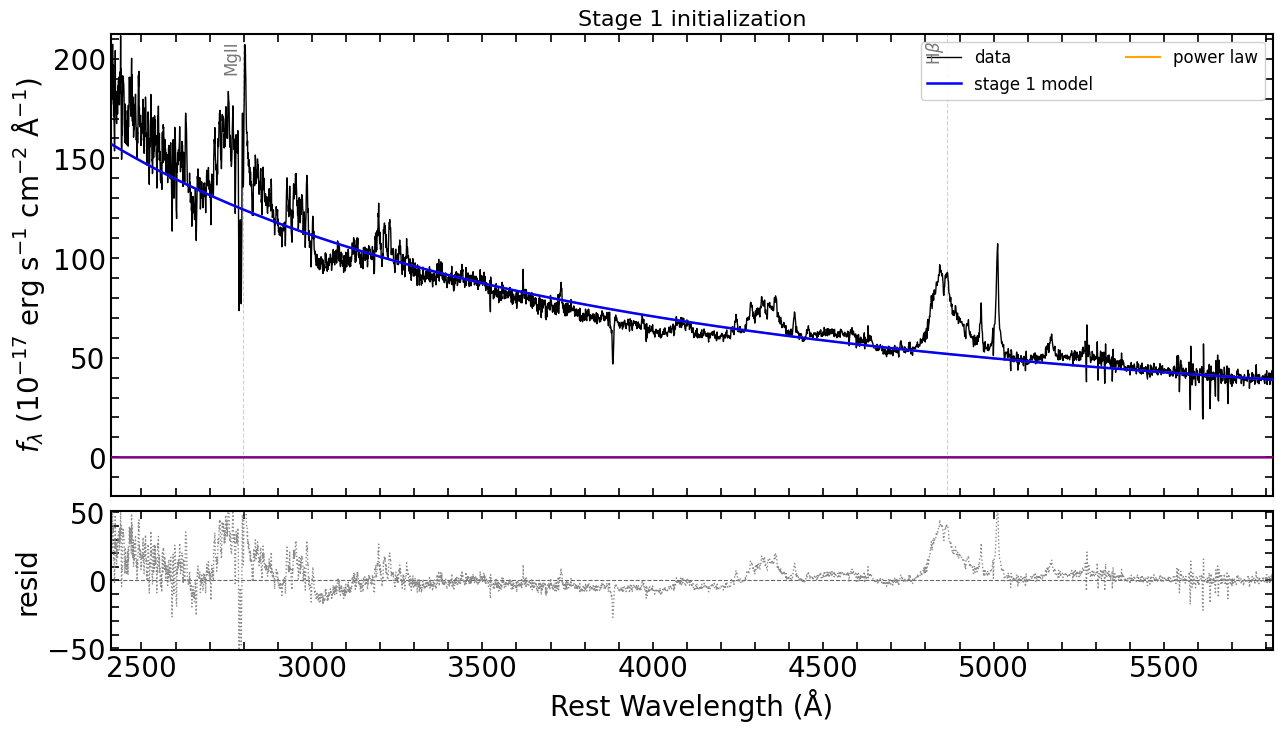

100%|██████████| 400/400 [00:05<00:00, 67.83it/s, init loss: 6639.6029, avg. loss [381-400]: 5499.5903] 


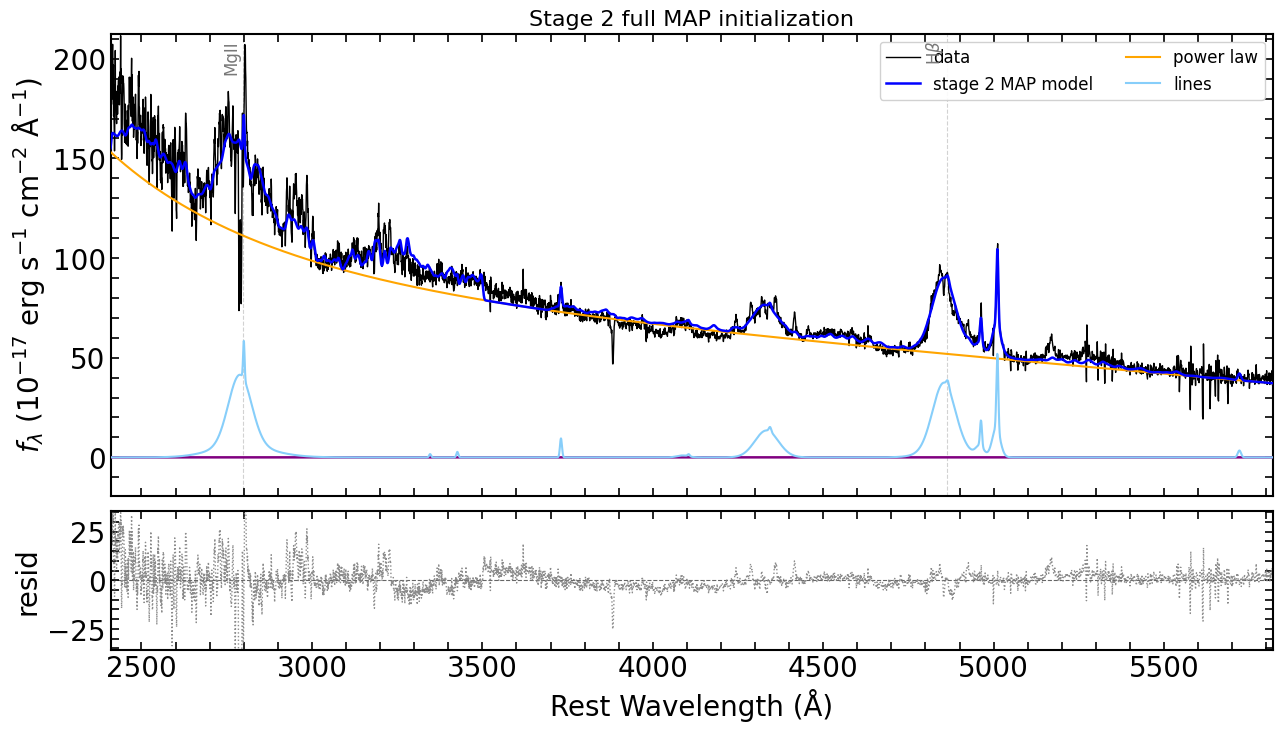

max data        : 211.55670693958675
max total model : 171.7855886787142
max PL          : 153.1881609379309
max host        : 0.0
max FeII UV     : 24.915805846167324
max FeII opt    : 4.428445363638758
max Balmer cont : 0.0
max lines       : 58.42570926899984


sample: 100%|██████████| 300/300 [03:28<00:00,  1.44it/s, 127 steps of size 2.81e-02. acc. prob=0.85]



                                           mean       std    median      5.0%     95.0%     n_eff     r_hat
                          Fe_FWHM_std     -2.01      0.12     -2.03     -2.24     -1.86     92.66      1.02
                         Fe_shift_std      0.69      0.16      0.69      0.40      0.91     66.14      1.02
                       Fe_uv_norm_std      2.85      0.04      2.84      2.79      2.92     34.21      1.06
             PL_apparent_log_norm_std      1.03      0.00      1.03      1.02      1.03     76.35      1.01
                PL_apparent_slope_std      0.08      0.03      0.08      0.03      0.11     49.03      1.02
                   frac_fe_jitter_std     -0.11      0.68     -0.17     -1.10      1.03     60.71      0.99
                      frac_jitter_std      1.01      0.13      1.00      0.80      1.20     57.71      0.99
          line_OIII_wing_log_fwhm_std      0.27      0.60      0.08     -0.42      1.16     13.55      1.03
                line_amp_Fe

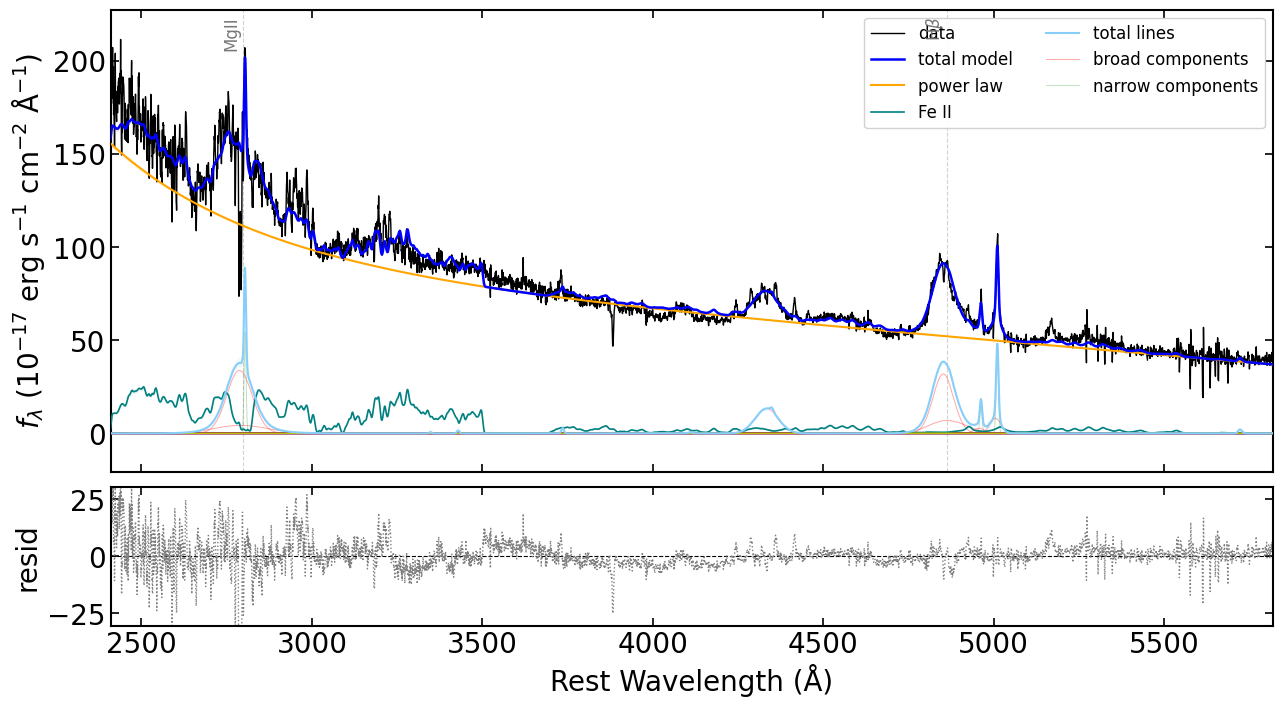

In [4]:
cfg = FitConfig(
    observation=Observation(
        object_id=sdss_filename,
        redshift=z,
        ra=ra,
        dec=dec,
        apply_mw_deredden=True,
    ),
    spectroscopy=SpectroscopyData(
        wave_obs=lam,
        fluxes=flux,
        errors=err,
        resolving_power=2000
    ),
    continuum=ContinuumConfig(
        fit_power_law=True,
        fit_feii=True,
        fit_balmer_continuum=False,
        fit_polynomial_tilt=True,
        fit_reddening=True,
    ),
    host=HostConfig(enabled=False, dsps_ssp_fn='../tempdata.h5'),
    lines=LineConfig(enabled=True, include_high_ionization_lines=True),
    inference=InferenceConfig(
        method='optax+nuts',
        map_steps=600,
        learning_rate=1e-2,
        num_warmup=200,
        num_samples=100,
        num_chains=1,
        dense_mass=False,
        line_block_dense_mass=True,
        standardize_active_priors=True,
        plot_init=True,
        max_tree_depth=8,
        target_accept_prob=0.82,
    ),
    output=OutputConfig(output_path='.', save_result=False, plot_fig=True, save_fig=False, show_plot=True),
    prior_config=prior_config,
)

q = JAXQSOFit(cfg)
result = q.fit()
q.nuts_diagnostics


In [ ]:
# Native Fe II template-shape comparison (before fitted broadening/shifts).
import matplotlib.pyplot as plt
from jaxsedfit import FitConfig as SEDFitConfig
from jaxsedfit.preload import _load_templates as load_sed_templates

sed_templates = load_sed_templates(SEDFitConfig())
sed_fe = np.interp(
    q.wave,
    sed_templates.feii_wave,
    sed_templates.feii_lumin,
    left=0.0,
    right=0.0,
)
spectral_fe = q._fe_uv_flux_on_wave + q._fe_op_flux_on_wave

def unit_peak(values):
    values = np.asarray(values, dtype=float)
    peak = np.nanmax(np.abs(values))
    return values / peak if np.isfinite(peak) and peak > 0 else values

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(q.wave, unit_peak(spectral_fe), color='black', lw=1.2, label='JAXQSOFit UV + optical Fe II')
ax.plot(q.wave, unit_peak(sed_fe), color='tab:orange', lw=1.2, alpha=0.85, label='JAXSEDFit Fe II')
ax.set(xlabel=r'Rest wavelength [$\AA$]', ylabel='Unit-peak template flux', xlim=(q.wave.min(), q.wave.max()))
ax.legend(frameon=False)
fig.tight_layout()


In [5]:
q.plot_mcmc_diagnostics(
    param_names='Fe_uv_FWHM',
    do_trace=True,
    do_corner=True,
    max_vector_elems=2,
    corner_bins=25,
    corner_max_points=1500,
)

